## Task 1 : Maths & Adv Stats 

In [2]:
import json
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
ROOT = Path("..")
RAW_CSV = ROOT / "data" / "raw" / "set_d.csv"
OUT = ROOT / "outputs"
FIG = OUT / "figures"
MODELS = ROOT / "models"
for p in (OUT, FIG, MODELS):
    p.mkdir(parents=True, exist_ok=True)

import sklearn, scipy, tensorflow as tf
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scipy       :", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("tensorflow  :", tf.__version__)

tf.random.set_seed(RANDOM_STATE)

numpy       : 2.5.3
pandas      : 2.3.2
scipy       : 1.16.2
scikit-learn: 1.8.0
tensorflow  : 2.21.0


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(404)
n = 300
cols = ['visits', 'recency', 'engagement', 'spend']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, -0.9, 1.1, 0.4])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["response"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_d.csv", index=False)

print("Dataset created:", df.shape)

Dataset created: (305, 7)


In [4]:
import matplotlib.pyplot as plt
df = pd.read_csv("data/raw/set_d.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (305, 7)
   record_id  visits  recency  engagement  spend group  response
0          1   53.96    43.84       54.57  58.93    G2         1
1          2     NaN    49.75       52.97  63.64    G2         1
2          3   35.39    66.52       44.98  47.33    G2         0
3          4   45.01    42.80       47.62  54.48    G1         1
4          5   53.84    53.72       48.33  58.30    G2         1


### M1 — Descriptive Statistics 

In [5]:
clean = df.drop_duplicates()

fit, test = __import__("sklearn.model_selection", fromlist=["train_test_split"]).train_test_split(
    clean,
    test_size=0.20,
    random_state=42,
    stratify=clean["response"]
)

fit, val = __import__("sklearn.model_selection", fromlist=["train_test_split"]).train_test_split(
    fit,
    test_size=0.20,
    random_state=42,
    stratify=fit["response"]
)

visits = fit["visits"].dropna()

print("Observed n:", len(visits))
print("Mean:", visits.mean())
print("Median:", visits.median())
print("Sample standard deviation:", visits.std())

Observed n: 181
Mean: 49.43613259668508
Median: 49.61
Sample standard deviation: 10.151904991680045


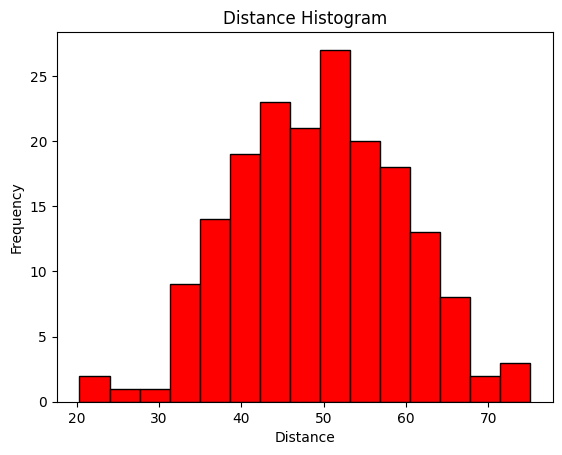

In [6]:
plt.hist(visits, bins=15, edgecolor="black", color='red')
plt.title("Distance Histogram")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** The mean and median show the central value of visits, while standard deviation shows its spread. The histogram shows how distance values are distributed.

In [7]:
print("Fit records:", len(fit))
print("Validation records:", len(val))
print("Test records:", len(test))

Fit records: 192
Validation records: 48
Test records: 60


### Statistical Inference

In [47]:
from scipy import stats

g1 = fit.loc[fit["group"] == "G1", "visits"].dropna()
g2 = fit.loc[fit["group"] == "G2", "visits"].dropna()

t, p = stats.ttest_ind(g1, g2, equal_var=False)

print("H0: Mean distance of G1 and G2 is equal.")
print("H1: Mean distance of G1 and G2 is different.")
print("G1 count:", len(g1))
print("G2 count:", len(g2))
print("t-statistic:", t)
print("p-value:", p)

distance = fit["visits"].dropna()
mean = distance.mean()
se = stats.sem(distance)

ci = stats.t.interval(
    0.95,
    len(visits) - 1,
    loc=mean,
    scale=se
)

print("95% confidence interval:", ci)

H0: Mean distance of G1 and G2 is equal.
H1: Mean distance of G1 and G2 is different.
G1 count: 80
G2 count: 101
t-statistic: -0.173996296590812
p-value: 0.8620806843011626
95% confidence interval: (np.float64(47.94716190950473), np.float64(50.925103283865425))


**Interpretation:** Welch's t-test compares the two group means without assuming equal variances. The confidence interval gives a reasonable range for the overall observed mean; the result does not prove causation.

### Linear Algebra

In [48]:
data = fit[["visits", "engagement"]].dropna().to_numpy()

center = data - data.mean(axis=0)
cov = (center.T @ center) / (len(data) - 1)

values, vectors = np.linalg.eigh(cov)

share = values[-1] / values.sum()

print("Rows used:", len(data))
print("Covariance matrix:")
print(cov)
print("Eigenvalues:", values)
print("Largest eigenvalue:", values[-1])
print("Variance share:", share)
print("Principal direction:", vectors[:, -1])

Rows used: 181
Covariance matrix:
[[103.06117496   4.11811311]
 [  4.11811311 103.65708913]]
Eigenvalues: [ 99.23025399 107.4880101 ]
Largest eigenvalue: 107.48801010083828
Variance share: 0.5199734555224486
Principal direction: [0.6811152  0.73217627]


**Interpretation:** The covariance matrix shows how visits and engagement vary together. The largest eigenvalue represents the principal direction with the largest share of variance.

## Task 2 Data Preprocessing & Feature Engineering

### Audit and Partition 

In [50]:
print("Raw shape:", df.shape)
print("Exact duplicates:", df.duplicated().sum())
print("Missing values:")
print(df.isna().sum())
print("Target counts:")
print(df["response"].value_counts())

print("Clean shape:", clean.shape)
print("Unique records:", clean["record_id"].nunique())

ids = pd.concat([
    fit[["record_id"]].assign(partition="fit"),
    val[["record_id"]].assign(partition="validation"),
    test[["record_id"]].assign(partition="test")
])

ids.to_csv("splits.csv", index=False)

print("Fit:", len(fit))
print("Validation:", len(val))
print("Test:", len(test))
print("Fit-Test overlap:", len(set(fit.record_id) & set(test.record_id)))
print("Fit-Validation overlap:", len(set(fit.record_id) & set(val.record_id)))
print("Validation-Test overlap:", len(set(val.record_id) & set(test.record_id)))

Raw shape: (305, 7)
Exact duplicates: 5
Missing values:
record_id      0
visits        16
recency       15
engagement     0
spend          0
group          0
response       0
dtype: int64
Target counts:
response
1    177
0    128
Name: count, dtype: int64
Clean shape: (300, 7)
Unique records: 300
Fit: 192
Validation: 48
Test: 60
Fit-Test overlap: 0
Fit-Validation overlap: 0
Validation-Test overlap: 0


**Interpretation:** Five duplicate rows are removed, leaving 300 unique records. The three partitions are disjoint, so validation and test records are not mixed with training records.

### Transform and Engineer

In [51]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num = ['visits', 'recency', 'engagement', 'spend']

# Missing values
imputer = SimpleImputer(strategy="median")

fit_num = pd.DataFrame(
    imputer.fit_transform(fit[num]),
    columns=num,
    index=fit.index
)

val_num = pd.DataFrame(
    imputer.transform(val[num]),
    columns=num,
    index=val.index
)

test_num = pd.DataFrame(
    imputer.transform(test[num]),
    columns=num,
    index=test.index
)

# Engineered feature
fit_num["engineered_feature"] = fit_num["recency"] / (fit_num["spend"] + 1)
val_num["engineered_feature"] = val_num["recency"] / (val_num["spend"] + 1)
test_num["engineered_feature"] = test_num["recency"] / (test_num["spend"] + 1)

all_num = num + ["engineered_feature"]

# Scaling
scaler = StandardScaler()

fit_scale = scaler.fit_transform(fit_num[all_num])
val_scale = scaler.transform(val_num[all_num])
test_scale = scaler.transform(test_num[all_num])

# Encoding
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

fit_group = encoder.fit_transform(fit[["group"]])
val_group = encoder.transform(val[["group"]])
test_group = encoder.transform(test[["group"]])

# Final features
x_fit = np.hstack([fit_scale, fit_group])
x_val = np.hstack([val_scale, val_group])
x_test = np.hstack([test_scale, test_group])

features = all_num + list(encoder.get_feature_names_out(["group"]))

print("Fit shape:", x_fit.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)

Fit shape: (192, 7)
Validation shape: (48, 7)
Test shape: (60, 7)


**Interpretation:** Missing numeric values are filled using medians learned only from fit data. The engineered feature is created before scaling, and group is one-hot encoded without scaling.

### Leakage Evidence

In [53]:
print("All fit values finite:", np.isfinite(x_fit).all())
print("All validation values finite:", np.isfinite(x_val).all())
print("All test values finite:", np.isfinite(x_test).all())

print("record_id is not a feature.")
print("response is not a feature.")
print("Test data is not used to fit imputer, encoder or scaler.")

All fit values finite: True
All validation values finite: True
All test values finite: True
record_id is not a feature.
response is not a feature.
Test data is not used to fit imputer, encoder or scaler.


**Interpretation:** `record_id` and the target `response` are excluded from model features. Preprocessing is fitted only on fit data, which helps prevent data leakage.

## Task 3 Supervised Learning

### Baseline and Classifier

In [55]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

y_fit = fit["response"]
y_test = test["response"]

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_fit, y_fit)

log = LogisticRegression(max_iter=1000, random_state=42)
log.fit(x_fit, y_fit)

print("Target: response")
print("Predictors:", features)
print("Dummy classifier and Logistic Regression trained.")

Target: response
Predictors: ['visits', 'recency', 'engagement', 'spend', 'engineered_feature', 'group_G1', 'group_G2']
Dummy classifier and Logistic Regression trained.


### Holdout Evalution 

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

dummy_pred = dummy.predict(x_test)
log_pred = log.predict(x_test)
log_prob = log.predict_proba(x_test)[:, 1]

dummy_acc = accuracy_score(y_test, dummy_pred)

acc = accuracy_score(y_test, log_pred)
pre = precision_score(y_test, log_pred, zero_division=0)
rec = recall_score(y_test, log_pred, zero_division=0)
f1 = f1_score(y_test, log_pred, zero_division=0)

print("Dummy accuracy:", dummy_acc)
print("Logistic accuracy:", acc)
print("Logistic precision:", pre)
print("Logistic recall:", rec)
print("Logistic F1:", f1)

cm = confusion_matrix(y_test, log_pred)

pred = pd.DataFrame({
    "record_id": test["record_id"],
    "true_label": y_test,
    "predicted_label": log_pred,
    "class_1_probability": log_prob
})

pred.to_csv("logistic_predictions.csv", index=False)

Dummy accuracy: 0.5833333333333334
Logistic accuracy: 0.8166666666666667
Logistic precision: 0.8333333333333334
Logistic recall: 0.8571428571428571
Logistic F1: 0.8450704225352113


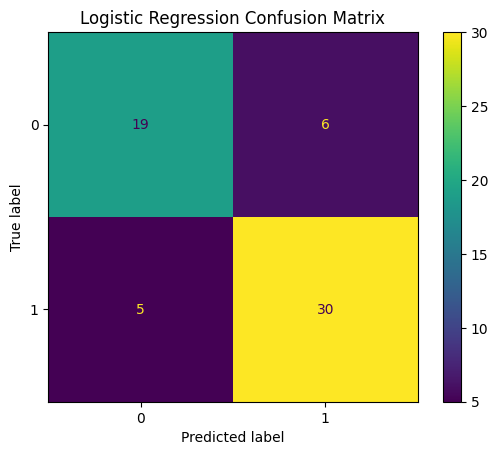

In [57]:
disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()


**Interpretation:** Accuracy shows total correct predictions, while precision, recall and F1 focus on the positive late-delivery class. `zero_division=0` safely handles an undefined precision or recall case.

### Interpretation

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_pred)

print("False positive:", cm[0, 1])
print("False negative:", cm[1, 0])
print("A false positive means an on-time delivery is predicted as response.")
print("A false negative means a late delivery is predicted as on-time.")

False positive: 6
False negative: 5
A false positive means an on-time delivery is predicted as response.
A false negative means a late delivery is predicted as on-time.


**Interpretation:** A false positive can create unnecessary operational attention. A false negative can miss a late-delivery warning, so both error types are useful to inspect.

## Task 4 Unsupervised Learning

### K-Means and Selection

In [60]:
import warnings
warnings.filterwarnings("ignore")

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_data = fit_scale
result = []

for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    label = model.fit_predict(cluster_data)

    result.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(cluster_data, label)
    })

result = pd.DataFrame(result)
print(result)

best = result.sort_values(
    ["silhouette", "k"],
    ascending=[False, True]
).iloc[0]

best_k = int(best["k"])

print("Selected k:", best_k)
result.to_csv("k_selection_scores.csv", index=False)

   k     inertia  silhouette
0  2  709.139419    0.241329
1  3  616.805612    0.194449
2  4  550.926309    0.178987
Selected k: 2


**Interpretation:** K-Means is tested with k=2, 3 and 4. The k with the highest silhouette score is selected; if scores tie, the smaller k is selected.

### Segment Interpretion

In [63]:
model = KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels = model.fit_predict(cluster_data)

profile = fit_num.copy()
profile["cluster"] = labels

profile = profile.groupby("cluster")[all_num].mean()

print(profile)

profile.to_csv("cluster_profiles.csv")
print("Cluster IDs are only labels; they are not target classes.")

            visits    recency  engagement      spend  engineered_feature
cluster                                                                 
0        49.186271  47.154915   51.393136  55.690169            0.837276
1        49.860405  55.721622   50.377838  42.279730            1.305219
Cluster IDs are only labels; they are not target classes.


**Interpretation:** Cluster profiles show the average operational values for each segment. A practical action can be based on the segment's visits, recency, engagement and spendprofile; cluster IDs themselves have no target meaning.

## Task 5 Deep Learning up to ANN

### ANN Architecture and Compilation

In [64]:
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

ann = keras.Sequential([
    keras.layers.Input(shape=(x_fit.shape[1],)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann.summary()
print("Trainable parameters:", ann.count_params())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 273


**Interpretation:** The ANN has 16 and 8 ReLU hidden units and one sigmoid output. Sigmoid gives a binary probability, and binary cross-entropy is used for the binary target.

### Training and Validation

In [67]:
early = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = ann.fit(
    x_fit,
    y_fit,
    validation_data=(x_val, val["response"]),
    epochs=50,
    batch_size=16,
    callbacks=[early],
    verbose=1
)

print("Actual epochs:", len(history.history["loss"]))
print("Random seed: 42")

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8229 - loss: 0.3849 - val_accuracy: 0.8958 - val_loss: 0.3106
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8229 - loss: 0.3841 - val_accuracy: 0.8958 - val_loss: 0.3103
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8229 - loss: 0.3834 - val_accuracy: 0.8958 - val_loss: 0.3101
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8229 - loss: 0.3826 - val_accuracy: 0.8958 - val_loss: 0.3100
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8229 - loss: 0.3819 - val_accuracy: 0.8958 - val_loss: 0.3098
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8229 - loss: 0.3812 - val_accuracy: 0.8958 - val_loss: 0.3097
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8229 - loss: 0.3806 - val_accuracy: 0.8958 - val_loss: 0.3094
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8229 - loss: 0.3801 - val_accuracy: 0.8958 - v

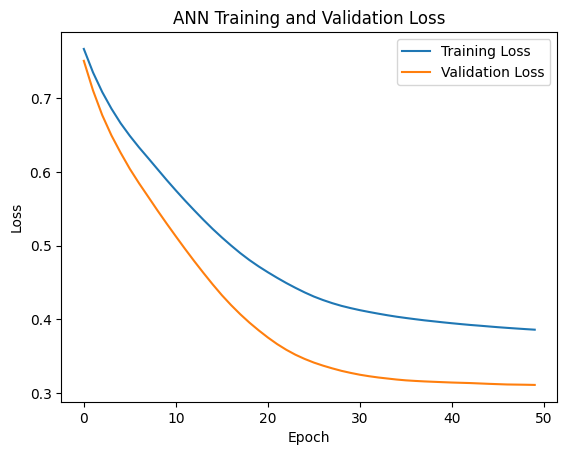

In [66]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Interpretation:** Early stopping keeps the best validation-loss model. A training loss that keeps falling while validation loss rises can indicate overfitting.

### Comparison and Evidence

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

prob = ann.predict(x_test, verbose=0).ravel()
pred = (prob >= 0.5).astype(int)

ann_acc = accuracy_score(y_test, pred)
ann_pre = precision_score(y_test, pred, zero_division=0)
ann_rec = recall_score(y_test, pred, zero_division=0)
ann_f1 = f1_score(y_test, pred, zero_division=0)

print("ANN accuracy:", ann_acc)
print("ANN precision:", ann_pre)
print("ANN recall:", ann_rec)
print("ANN F1:", ann_f1)
print("Logistic F1:", f1)

compare = pd.DataFrame({
    "model": ["Logistic Regression", "ANN"],
    "accuracy": [acc, ann_acc],
    "precision": [pre, ann_pre],
    "recall": [rec, ann_rec],
    "f1": [f1, ann_f1]
})

print(compare)

ann_pred = pd.DataFrame({
    "record_id": test["record_id"],
    "true_label": y_test,
    "predicted_label": pred,
    "class_1_probability": prob
})

ann_pred.to_csv("ann_predictions.csv", index=False)

ann.save("delivery_risk_ann.keras")
compare.to_csv("ann_logistic_comparison.csv", index=False)

ANN accuracy: 0.8166666666666667
ANN precision: 0.8333333333333334
ANN recall: 0.8571428571428571
ANN F1: 0.8450704225352113
Logistic F1: 0.8450704225352113
                 model  accuracy  precision    recall       f1
0  Logistic Regression  0.816667   0.833333  0.857143  0.84507
1                  ANN  0.816667   0.833333  0.857143  0.84507


**Interpretation:** The ANN is evaluated on the same untouched 60 test records as Logistic Regression. Compare their F1 values and consider the simpler model when its test performance is similar.